In [32]:
import sys
sys.path.append('/Users/mariana/Documents/col/lts4/survan')
sys.path.append('/Users/mariana/Documents/col/lts4/tdsurv/lib')

import h5py
from tdsurv import CoxPH
from tdsurv import concordance_index as tdsurv_ci
from deep_lambda_cox import DeepLambdaSA

from utils import concordance_index, unroll_time, unroll, score

import yaml
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# NASA Dataset

In [33]:
config_path = '../configs/config_nasa.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [34]:
def load_preprocessed_dataset(data_path):
    data = h5py.File(data_path, 'r')
    seqs = np.array(data['seqs'])
    ts = np.array(data['ts'])
    cs = np.array(data['cs']).astype(bool)
    h_ws = np.array(data['h_ws']).astype(bool)
    mask = np.array(data['mask']).astype(bool)
    h_tgt = np.array(data['target'])
    return seqs, ts, cs, h_tgt, h_ws, mask

In [35]:
data = load_preprocessed_dataset(config['dataset_kwargs']['data_path'])

In [36]:
task = config['dataset_name']
task

'nasa'

In [37]:
agent = DeepLambdaSA(config, 42)

In [38]:
seqs = agent.data['seqs'].astype(np.float32)
ts = agent.data['ts']
cs = agent.data['cs']

n, H, _ = seqs.shape

d = seqs.shape[2]
n_feats = d - 1
# xs = jnp.concatenate((xs, jnp.tile(jnp.eye(H), (n, 1, 1))), axis=-1)
# agent.integrated_brier_score(xs[:,0], ts, cs)

In [39]:
test_size = 0.2
size = int(n * (1-test_size))
size

160

In [40]:
seqs.shape

(200, 363, 17)

In [41]:
seqs[9]

array([[ 0.        , -0.6338654 ,  1.3526524 , ..., -1.3368472 ,
         1.1368748 ,  2.1878276 ],
       [ 0.        , -0.6338654 ,  1.3526524 , ..., -1.3368472 ,
         1.1368748 ,  2.1878276 ],
       [ 0.01      ,  0.4148006 ,  1.6934427 , ..., -2.0180354 ,
         1.1954376 ,  0.02957297],
       ...,
       [ 3.59      ,  0.09564137, -1.0328792 , ...,  3.4314702 ,
        -1.966951  , -1.6084669 ],
       [ 3.6       ,  0.09564137, -1.0328792 , ...,  3.4314702 ,
        -1.966951  , -1.6084669 ],
       [ 3.61      ,  0.09564137, -1.0328792 , ...,  3.4314702 ,
        -1.966951  , -1.6084669 ]], dtype=float32)

In [42]:
# 5-fold cross-validation
rng = np.random.default_rng(seed=0)
n_folds = 5
zs = np.append(((n / n_folds) * np.arange(n_folds)).astype(int), n)
idx = rng.permutation(n)
idx = jnp.array(idx)

def get_fold(fold):
    z1 = zs[fold]
    z2 = zs[fold + 1]
    idx_train = jnp.concatenate((idx[:z1], idx[z2:]))
    idx_valid = idx[z1:z2]
    return (
        (seqs[idx_train], ts[idx_train], cs[idx_train]),
        (seqs[idx_valid], ts[idx_valid], cs[idx_valid]),
        (idx_train, idx_valid)
    )

In [43]:
(seqs_t, ts_t, cs_t), (seqs_v, ts_v, cs_v), (i_tr, i_val) = get_fold(1)
seqs_t.shape, seqs_v.shape

((160, 363, 17), (40, 363, 17))

In [44]:
%%time

# sizes = [10, 30, 50, 100]  # Test size is 20% of dataset 
sizes = [160]

ci_is = np.zeros((n_folds, len(sizes)))
ci_lm = np.zeros((n_folds, len(sizes)))
ci_td = np.zeros((n_folds, len(sizes)))
ci_dtd = np.zeros((n_folds, len(sizes)))

ibs_is = np.zeros((n_folds, len(sizes)))
ibs_lm = np.zeros((n_folds, len(sizes)))
ibs_td = np.zeros((n_folds, len(sizes)))
ibs_dtd = np.zeros((n_folds, len(sizes)))

l2 = 0.0

for fold in range(n_folds):
    (seqs_t, ts_t, cs_t), (seqs_v, ts_v, cs_v), (i_tr, i_val) = get_fold(fold)
    for i, size in enumerate(sizes):
        print(".", end="")
        seqs_, ts_, cs_ = unroll(seqs_t[:size], ts_t[:size], cs_t[:size])

        config['axis'] = 1

        model = CoxPH(horizon=H, n_feats=d)
        
        # Initial state.
        model.params = np.zeros_like(model.params)
        model.fit(seqs_t[:size], ts_t[:size], cs_t[:size], lambda_=1.0, l2=l2)
        ci_is[fold, i] = tdsurv_ci(model.score(seqs_v[:, 0]), ts_v, cs_v)
        ibs_is[fold, i] = model.integrated_brier_score(seqs_v[:, 0], ts_v, cs_v)
        
        # Landmarking.
        model.params = np.zeros_like(model.params)
        model.fit(seqs_, ts_, cs_, lambda_=1.0, l2=l2)
        ci_lm[fold, i] = tdsurv_ci(model.score(seqs_v[:, 0]), ts_v, cs_v)
        ibs_lm[fold, i] = model.integrated_brier_score(seqs_v[:, 0], ts_v, cs_v)
        
        # Temporal difference.
        model.params = np.zeros_like(model.params)
        model.fit(seqs_, ts_, cs_, lambda_=0.0, n_iters=100, l2=l2)
        ci_td[fold, i] = tdsurv_ci(model.score(seqs_v[:, 0]), ts_v, cs_v)
        ibs_td[fold, i] = model.integrated_brier_score(seqs_v[:, 0], ts_v, cs_v)

        # Deep TD
        config['axis'] = 2
        model = DeepLambdaSA(config, seed=42)
        model.lambda_ = 0.0

        seq_tr = model.data['seqs'][i_tr][:size]
        seq_val = model.data['seqs'][i_val]
        ts_tr = model.data['ts'][i_tr][:size]
        ts_val = model.data['ts'][i_val]
        cs_tr = model.data['cs'][i_tr][:size]
        cs_val = model.data['cs'][i_val]
        ys_tr = model.data['target'][i_tr][:size]
        ys_val = model.data['target'][i_val]
        m_tr = model.data['mask'][i_tr][:size]
        m_val = model.data['mask'][i_val]
        h_tr = model.data['h_ws'][i_tr][:size]
        h_val = model.data['h_ws'][i_val]

        assert np.all(seq_tr == seqs_t[:size])
        assert np.all(seq_val == seqs_v)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        train_gen.X = seq_tr
        train_gen.ts = ts_tr
        train_gen.cs = cs_tr
        train_gen.y = ys_tr
        train_gen.mask = m_tr
        train_gen.h_ws = h_tr

        _ = model.train(train_gen)
        surv = model.survival_curve(seq_val)
        scores = model.scores(seq_val, q=0.0)
        ci_dtd[fold, i] = concordance_index(scores, ts_val, cs_val)
        ibs_dtd[fold, i] = model.integrated_brier_score(surv[:,0], ts_val, cs_val)
        
    print()

.

KeyboardInterrupt: 

In [14]:
ibs_dtd

array([[0.17210612, 0.17497539, 0.16566966, 0.1806078 ],
       [0.1557766 , 0.14260767, 0.16306093, 0.16723741],
       [0.16652711, 0.16631387, 0.18426734, 0.17469698],
       [0.17652947, 0.13723407, 0.15486236, 0.14798015],
       [0.18045707, 0.17072624, 0.16928426, 0.16210268]])

In [32]:
all_res = [
    
    [(0, rw_ci_is, 'SA Init State'), 
     (1, rw_ci_lm, 'SA Landmarking'),
     (2, rw_ci_td, 'TCSA'),
     (3, rw_ci_dtd, 'DeepTCSA')],
    
    [(0, rw_ibs_is, 'SA Init State'), 
     (1, rw_ibs_lm, 'SA Landmarking'),
     (2, rw_ibs_td, 'TCSA'),
     (3, rw_ibs_dtd, 'DeepTCSA')]
]

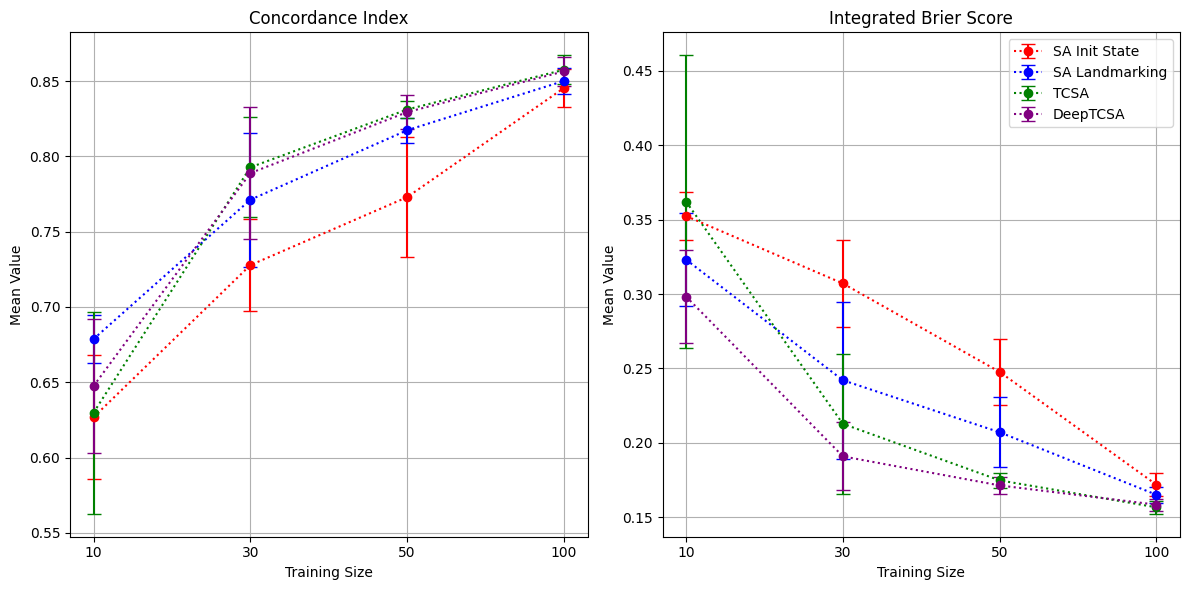

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# Define the two groups of arrays of shape (5, 4)
group1 = all_res[0]
group2 = all_res[1]

# Define the training sizes
training_sizes = [1, 2, 3, 4]

# Define colors for each array
colors = ['red', 'blue', 'green', 'purple']

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot each array in the first group
for i, array, label in group1:
    means = np.mean(array, axis=0)
    stds = np.std(array, axis=0)
    axes[0].errorbar(training_sizes, means, yerr=stds, fmt='o', linestyle=':', capsize=5, color=colors[i], label=label)

# Plot each array in the second group
for i, array, label in group2:
    means = np.mean(array, axis=0)
    stds = np.std(array, axis=0)
    axes[1].errorbar(training_sizes, means, yerr=stds, fmt='o', linestyle=':', capsize=5, color=colors[i], label=label)

# Add titles, labels, legends, and x-ticks to the first subplot
axes[0].set_title('Concordance Index')
axes[0].set_xlabel('Training Size')
axes[0].set_ylabel('Mean Value')
axes[0].set_xticks(training_sizes)
axes[0].set_xticklabels(sizes)
axes[0].grid()
# axes[0].legend()

# Add titles, labels, legends, and x-ticks to the second subplot
axes[1].set_title('Integrated Brier Score')
axes[1].set_xlabel('Training Size')
axes[1].set_ylabel('Mean Value')
axes[1].set_xticks(training_sizes)
axes[1].set_xticklabels(sizes)
axes[1].grid()
axes[1].legend()

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

In [39]:
means

array([0.56481692, 0.5914701 , 0.53014728, 0.50332616])

# Compile results and plot

In [29]:
all_res = [
    [(0, ci_is, 'SA Init State'), 
     (1, ci_lm, 'SA Landmarking'),
     (2, ci_td, 'TCSA'),
     (3, ci_dtd, 'DeepTCSA')],
    [(0, aids_ci_is, 'SA Init State'), 
     (1, aids_ci_lm, 'SA Landmarking'),
     (2, aids_ci_td, 'TCSA'),
     (3, aids_ci_dtd, 'DeepTCSA')],
    [(0, rw_ci_is, 'SA Init State'), 
     (1, rw_ci_lm, 'SA Landmarking'),
     (2, rw_ci_td, 'TCSA'),
     (3, rw_ci_dtd, 'DeepTCSA')],
    [(0, ibs_is, 'SA Init State'), 
     (1, ibs_lm, 'SA Landmarking'),
     (2, ibs_td, 'TCSA'),
     (3, ibs_dtd, 'DeepTCSA')],
    [(0, aids_ibs_is, 'SA Init State'), 
     (1, aids_ibs_lm, 'SA Landmarking'),
     (2, aids_ibs_td, 'TCSA'),
     (3, aids_ibs_dtd, 'DeepTCSA')],
    [(0, rw_ibs_is, 'SA Init State'), 
     (1, rw_ibs_lm, 'SA Landmarking'),
     (2, rw_ibs_td, 'TCSA'),
     (3, rw_ibs_dtd, 'DeepTCSA')]
]

NameError: name 'ci_is' is not defined

NameError: name 'all_res' is not defined

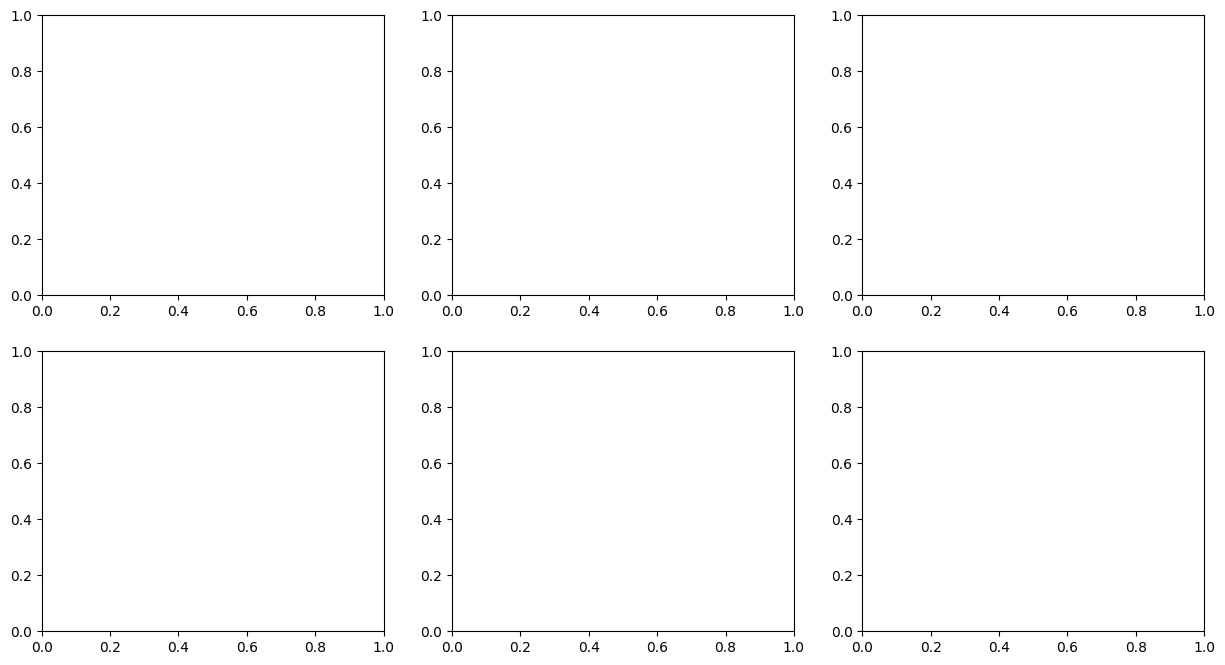

In [16]:

# Define colors for each key
colors = {'SA Init State': 'red', 'SA Landmarking': 'blue', 'TCSA': 'green', 'DeepTCSA': 'purple'}

# Prepare data for plotting
tasks = sizes
keys = colors.keys()


# Create a 2x3 grid for the plots
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

# Flatten the axs array to make it easier to iterate
axs = axs.flatten()

positions = np.arange(len(sizes))

# Loop through the subplots and plot your custom content
for i, ax in enumerate(axs):

    res = all_res[i]
    
    # Create boxplots
    for j, data, key in res:

        box = ax.boxplot(data, positions=positions + j * 0.2,
                         widths=0.2, patch_artist=True, boxprops=dict(facecolor=colors[key]))
    
    # Create legend
    if i == 0:
        legend_labels = [plt.Rectangle((0, 0), 1, 1, color=colors[key]) for key in keys]
        ax.legend(legend_labels, keys, loc='lower right')
    
    # Set labels and title
    ax.set_xticks(np.arange(len(tasks)) + 0.2 * (len(keys) - 1) / 2)
    ax.set_xticklabels(tasks)
    ax.grid()
    
    if i == 0:
        ax.set_ylabel('Concordance Index')
        ax.set_title(f'PBC2')
    if i == 1:
        ax.set_title(f'AIDS')
    if i == 2:
        ax.set_title(f'RW')
    if i == 3:
        ax.set_ylabel('Integrated Brier Score')
    if i > 2:
        ax.set_xlabel('Nb. of sequences')

# Adjust layout for better spacing
save_fig = True
if save_fig:
    plt.tight_layout()  # Ensures a tight layout
    plt.savefig("../../Figures/survan/smallDS_results.pdf".format(task), format="pdf")
    
# Show the plot
plt.show()

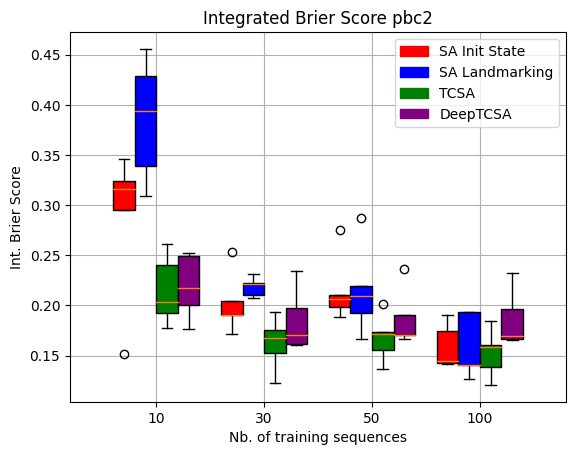

In [ ]:
save_fig = False

# Define colors for each key
colors = {'SA Init State': 'red', 'SA Landmarking': 'blue', 'TCSA': 'green', 'DeepTCSA': 'purple'}

# Prepare data for plotting
tasks = sizes
keys = colors.keys()

fig, ax = plt.subplots()
positions = np.arange(len(sizes))

# Create boxplots
for i, d, key in [(0, ibs_is, 'SA Init State'), 
                  (1, ibs_lm, 'SA Landmarking'),
                  (2, ibs_td, 'TCSA'),
                  (3, ci_dtd, 'DeepTCSA')]:
    data = d
    box = ax.boxplot(data, positions=positions + i * 0.2,
                     widths=0.2, patch_artist=True, boxprops=dict(facecolor=colors[key]))

# Create legend
legend_labels = [plt.Rectangle((0, 0), 1, 1, color=colors[key]) for key in keys]
ax.legend(legend_labels, keys, loc='upper right')

# Set labels and title
ax.set_xticks(np.arange(len(tasks)) + 0.2 * (len(keys) - 1) / 2)
ax.set_xticklabels(tasks)
ax.set_xlabel('Nb. of training sequences')
ax.set_ylabel('Int. Brier Score')
ax.set_title('Integrated Brier Score {}'.format(task))
ax.grid()

if save_fig:
    plt.tight_layout()  # Ensures a tight layout
    plt.savefig("../../Figures/survan/{}/Int_brier_score.pdf".format(task), format="pdf")

plt.show()

NameError: name 'save_fig' is not defined

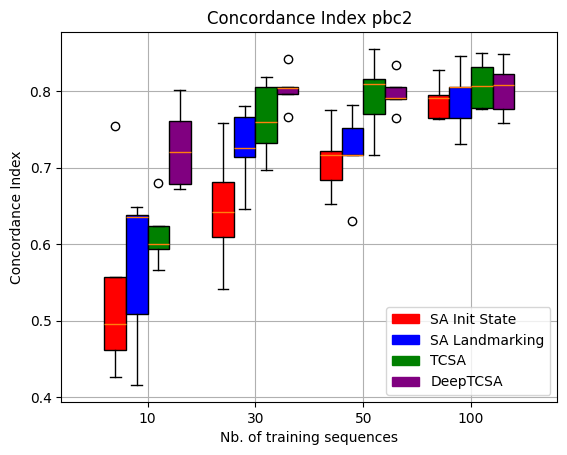

In [17]:

# Define colors for each key
colors = {'SA Init State': 'red', 'SA Landmarking': 'blue', 'TCSA': 'green', 'DeepTCSA': 'purple'}

# Prepare data for plotting
tasks = sizes
keys = colors.keys()

fig, ax = plt.subplots()
positions = np.arange(len(sizes))

# Create boxplots
for i, d, key in [(0, ci_is, 'SA Init State'), 
                  (1, ci_lm, 'SA Landmarking'),
                  (2, ci_td, 'TCSA'),
                  (3, ci_dtd, 'DeepTCSA')]:
    data = d
    box = ax.boxplot(data, positions=positions + i * 0.2,
                     widths=0.2, patch_artist=True, boxprops=dict(facecolor=colors[key]))

# Create legend
legend_labels = [plt.Rectangle((0, 0), 1, 1, color=colors[key]) for key in keys]
ax.legend(legend_labels, keys, loc='lower right')

# Set labels and title
ax.set_xticks(np.arange(len(tasks)) + 0.2 * (len(keys) - 1) / 2)
ax.set_xticklabels(tasks)
ax.set_xlabel('Nb. of training sequences')
ax.set_ylabel('Concordance Index')
ax.set_title('Concordance Index {}'.format(task))
ax.grid()

if save_fig:
    plt.tight_layout()  # Ensures a tight layout
    plt.savefig("../../Figures/survan/{}/Concordance_idx.pdf".format(task), format="pdf")

plt.show()